# Freight Rate Prediction — CRISP-DM

## Objective

Predict the posted freight rate of a load using historical freight data.

This project follows the CRISP-DM methodology:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Final Prediction

The development dataset contains labeled historical loads.
The final model will be used to predict rates for the unseen validation dataset.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)



### Importing the train_test and the validation data to pandas dataframe

In [2]:
df=pd.read_csv("data//train-test.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## First step in CRISP_DM is data understanding

In [3]:
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])

print("\nColumns:")
for column in df.columns:
    print(f"- {column}")

Number of rows: 48000
Number of columns: 14

Columns:
- load_id
- pickup
- delivery
- pickup_lat
- pickup_lon
- delivery_lat
- delivery_lon
- distance
- equipment
- weight
- date
- market_index
- quote_signal
- posted_rate


Data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


as we can see our target here is the posted_rate column

we can see there is missing values:
- weight 300 values is nan
- market_index 374 values is nan

Statistical summary

In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


missing values

In [7]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing["missing_percentage"] = (
    missing["missing_count"] / len(df) * 100
)

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing)

,missing_count,missing_percentage
market_index,374,0.779167
weight,300,0.625000
delivery,0,0.000000
pickup_lat,0,0.000000
load_id,0,0.000000
pickup,0,0.000000
delivery_lat,0,0.000000
pickup_lon,0,0.000000
distance,0,0.000000
delivery_lon,0,0.000000


Visualizing the  missing values

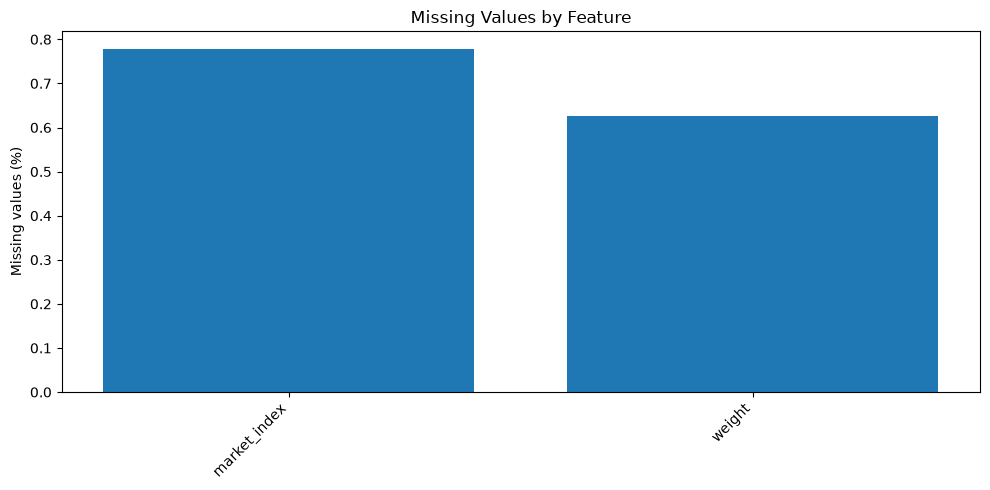

In [8]:
missing_plot = missing[missing["missing_count"] > 0]

if len(missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(
        missing_plot.index,
        missing_plot["missing_percentage"]
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing values (%)")
    plt.title("Missing Values by Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [30]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")

In [31]:
df[["weight", "market_index"]] = numeric_imputer.fit_transform(
    df[["weight", "market_index"]]
)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   pickup        48000 non-null  object        
 1   delivery      48000 non-null  object        
 2   pickup_lat    48000 non-null  float64       
 3   pickup_lon    48000 non-null  float64       
 4   delivery_lat  48000 non-null  float64       
 5   delivery_lon  48000 non-null  float64       
 6   distance      48000 non-null  float64       
 7   equipment     48000 non-null  object        
 8   weight        48000 non-null  float64       
 9   date          48000 non-null  datetime64[ns]
 10  market_index  48000 non-null  float64       
 11  quote_signal  48000 non-null  float64       
 12  posted_rate   48000 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(3)
memory usage: 4.8+ MB


Duplicate analysis

In [9]:
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


Check unique values

In [10]:
unique_summary = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[col].nunique(dropna=False) for col in df.columns],
})

display(unique_summary.sort_values("n_unique"))

,column,n_unique
8,equipment,3
6,delivery_lon,63
4,pickup_lon,63
1,pickup,64
5,delivery_lat,64
3,pickup_lat,64
2,delivery,64
10,date,304
7,distance,21204
9,weight,23679


Categorical columns

In [11]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
for col in categorical_columns:
    print(f"- {col}")

Categorical columns:
- load_id
- pickup
- delivery
- equipment
- date


In [28]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
for col in numerical_columns:
    print(f"- {col}")

Numerical columns:
- pickup_lat
- pickup_lon
- delivery_lat
- delivery_lon
- distance
- weight
- market_index
- quote_signal
- posted_rate


we will delete the id column just cause it is just an ID that will not affect anythink in our ML process 

In [16]:
df.drop(columns="load_id", inplace=True, errors="ignore")
df.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


Target disrubution

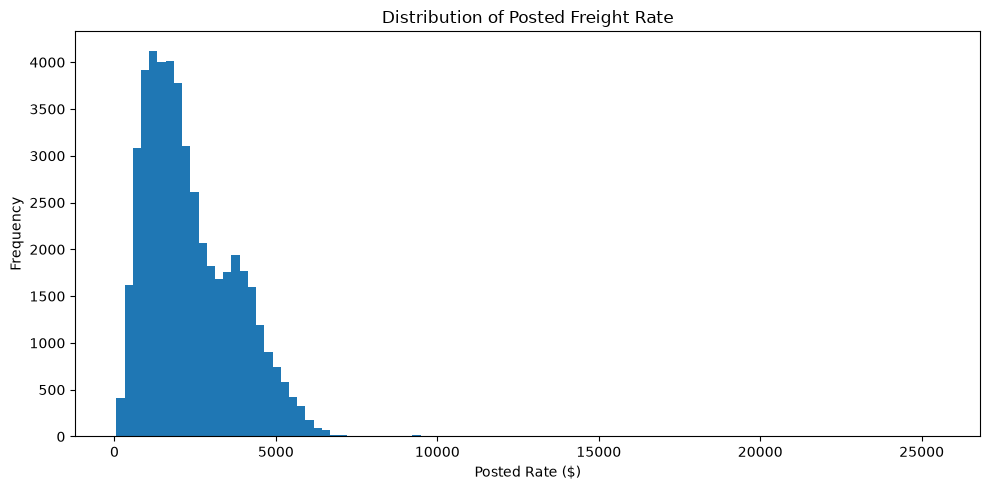

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["posted_rate"],
    bins=100
)

plt.xlabel("Posted Rate ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Posted Freight Rate")

plt.tight_layout()
plt.show()

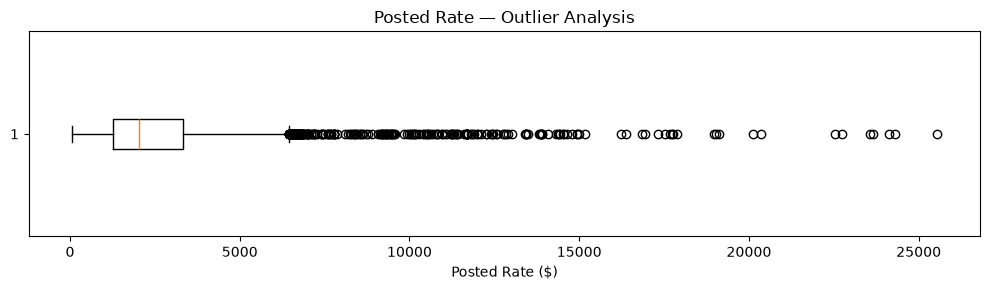

In [20]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["posted_rate"].dropna(),
    vert=False
)

plt.xlabel("Posted Rate ($)")
plt.title("Posted Rate — Outlier Analysis")

plt.tight_layout()
plt.show()

Target statistics

In [22]:
target_stats = {
    "mean": df["posted_rate"].mean(),
    "median": df["posted_rate"].median(),
    "std": df["posted_rate"].std(),
    "min": df["posted_rate"].min(),
    "max": df["posted_rate"].max(),
    "q1": df["posted_rate"].quantile(0.25),
    "q3": df["posted_rate"].quantile(0.75),
}

target_stats

{'mean': np.float64(2373.9806822916667),
 'median': np.float64(2030.76),
 'std': np.float64(1486.4932447622946),
 'min': np.float64(57.22),
 'max': np.float64(25533.0),
 'q1': np.float64(1251.5549999999998),
 'q3': np.float64(3330.75)}

Date conversion

In [23]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Invalid dates:", df["date"].isna().sum())

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Invalid dates: 0
Minimum date: 2025-01-01 00:00:00
Maximum date: 2025-10-31 00:00:00


Check chronological ordering

In [24]:
print("Already sorted by date:", df["date"].is_monotonic_increasing)

Already sorted by date: True


Target over time

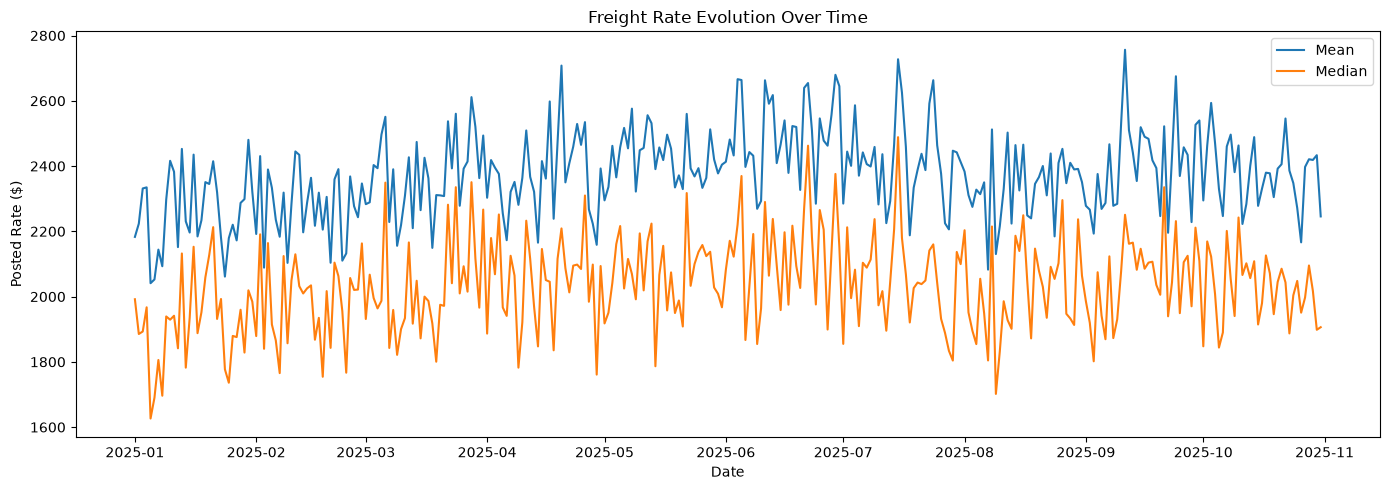

In [25]:
daily_rate = (
    df.groupby("date")["posted_rate"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_rate["date"],
    daily_rate["mean"],
    label="Mean"
)

plt.plot(
    daily_rate["date"],
    daily_rate["median"],
    label="Median"
)

plt.xlabel("Date")
plt.ylabel("Posted Rate ($)")
plt.title("Freight Rate Evolution Over Time")
plt.legend()

plt.tight_layout()
plt.show()

Numerical correlations

In [29]:
numeric_corr = (
    df[numerical_columns]
    .corr(numeric_only=True)["posted_rate"]
    .sort_values(ascending=False)
)

display(numeric_corr.to_frame("correlation_with_target"))

,correlation_with_target
posted_rate,1.000000
distance,0.908519
weight,0.034840
market_index,0.034165
quote_signal,-0.039858
pickup_lat,-0.090873
delivery_lat,-0.091970
pickup_lon,-0.255058
delivery_lon,-0.257086


we see that the distance has an important impact fort the target we need to check if the distance has no negative values

In [35]:
negative_distance = df[df["distance"] < 0]

print("Number of negative distances:", len(negative_distance))

Number of negative distances: 0


In [38]:
print(df["distance"].describe())

count    48000.000000
mean      1135.856654
std        728.564416
min         70.000000
25%        550.400000
50%        953.300000
75%       1645.525000
max       3439.800000
Name: distance, dtype: float64


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   pickup        48000 non-null  object        
 1   delivery      48000 non-null  object        
 2   pickup_lat    48000 non-null  float64       
 3   pickup_lon    48000 non-null  float64       
 4   delivery_lat  48000 non-null  float64       
 5   delivery_lon  48000 non-null  float64       
 6   distance      48000 non-null  float64       
 7   equipment     48000 non-null  object        
 8   weight        48000 non-null  float64       
 9   date          48000 non-null  datetime64[ns]
 10  market_index  48000 non-null  float64       
 11  quote_signal  48000 non-null  float64       
 12  posted_rate   48000 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(3)
memory usage: 4.8+ MB


In [47]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [48]:
df = df.drop(columns=["date"])

Now we will prepare the data for the training so we should split it into train and test 

In [57]:
categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

In [59]:
numeric_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos"
]

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [61]:
X=df.drop(columns="posted_rate", errors="ignore")
y=df["posted_rate"]

In [62]:
print(X.shape)
print(y.shape)

(48000, 21)
(48000,)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

## Training the models we will start with baseline model

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])

ridge_pipeline.fit(X_train, y_train)

y_pred = ridge_pipeline.predict(X_test)

Evaluating the First Model : Ridge

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 153.84
RMSE : 638.68
R²   : 0.8246


XGBoost Model

In [67]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

In [69]:

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE  : {mae_xgb:.2f}")
print(f"XGBoost RMSE : {rmse_xgb:.2f}")
print(f"XGBoost R²   : {r2_xgb:.4f}")

XGBoost MAE  : 183.73
XGBoost RMSE : 672.70
XGBoost R²   : 0.8054


Catboost Model

In [72]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100
)

0:	learn: 1075.1355298	test: 1097.8741923	best: 1097.8741923 (0)	total: 158ms	remaining: 2m 37s
100:	learn: 105.2419245	test: 149.6689112	best: 149.6689112 (100)	total: 6.63s	remaining: 59s
200:	learn: 89.8403753	test: 138.1406289	best: 137.8190314 (194)	total: 12.9s	remaining: 51.4s
300:	learn: 84.7115371	test: 135.1716144	best: 135.1716144 (300)	total: 19.4s	remaining: 45.1s
400:	learn: 81.4737578	test: 134.5352974	best: 134.5295457 (398)	total: 25.8s	remaining: 38.5s
500:	learn: 79.5174892	test: 133.1270256	best: 133.1090653 (499)	total: 32.2s	remaining: 32s
600:	learn: 78.0803038	test: 133.1130485	best: 133.0430653 (590)	total: 38.6s	remaining: 25.6s
700:	learn: 76.7821056	test: 133.1146146	best: 132.9671390 (645)	total: 44.9s	remaining: 19.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 132.967139
bestIteration = 645

Shrink model to first 646 iterations.


CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=100)

In [74]:
y_pred_cat = catboost_model.predict(X_test)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print("CatBoost")
print(f"MAE  : {mae_cat:,.2f}")
print(f"RMSE : {rmse_cat:,.2f}")
print(f"R²   : {r2_cat:.4f}")

CatBoost
MAE  : 132.97
RMSE : 640.94
R²   : 0.8234


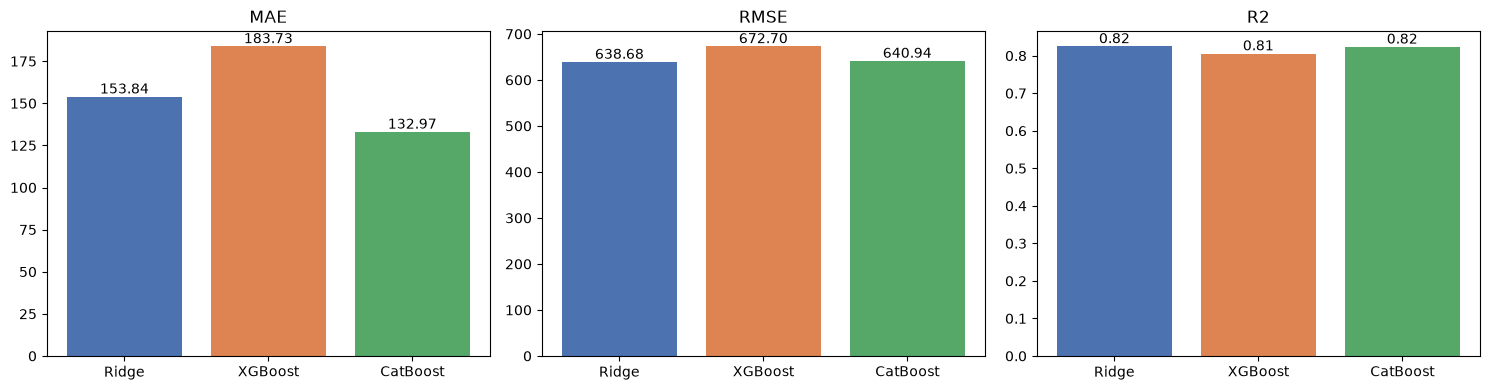

,Model,MAE,RMSE,R2
0,Ridge,153.838239,638.682235,0.824598
1,XGBoost,183.728192,672.696538,0.805417
2,CatBoost,132.967141,640.942344,0.823354


In [79]:
metrics_df = pd.DataFrame({
    "Model": ["Ridge", "XGBoost", "CatBoost"],
    "MAE": [mae, mae_xgb, mae_cat],
    "RMSE": [rmse, rmse_xgb, rmse_cat],
    "R2": [r2, r2_xgb, r2_cat]
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    bars = ax.bar(metrics_df["Model"], metrics_df[metric], color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title(metric)
    ax.bar_label(bars, fmt="%.2f")

plt.tight_layout()
plt.show()

metrics_df

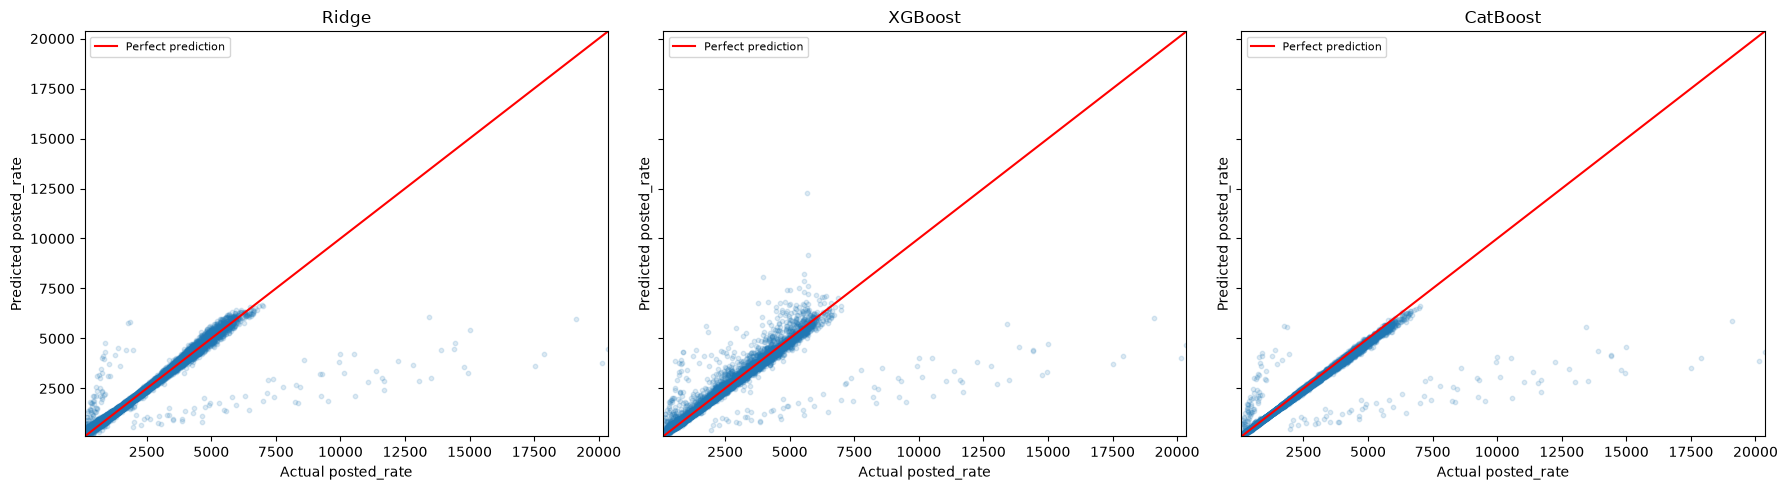

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

preds = {
    "Ridge": y_pred,
    "XGBoost": y_pred_xgb,
    "CatBoost": y_pred_cat
}

lims = [min(y_test.min(), min(p.min() for p in preds.values())),
        max(y_test.max(), max(p.max() for p in preds.values()))]

for ax, (name, p) in zip(axes, preds.items()):
    ax.scatter(y_test, p, alpha=0.15, s=10)
    ax.plot(lims, lims, color="red", linewidth=1.5, label="Perfect prediction")
    ax.set_title(name)
    ax.set_xlabel("Actual posted_rate")
    ax.set_ylabel("Predicted posted_rate")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

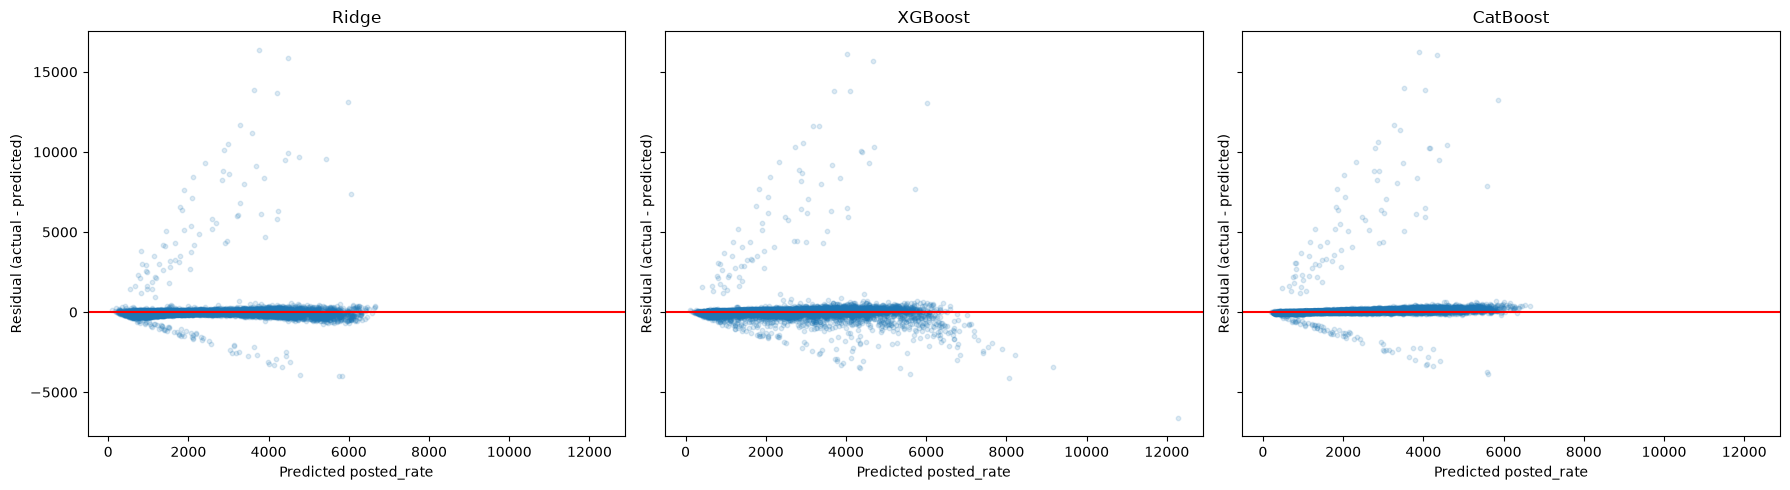

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

residuals = {
    "Ridge": y_test - y_pred,
    "XGBoost": y_test - y_pred_xgb,
    "CatBoost": y_test - y_pred_cat
}

for ax, (name, res) in zip(axes, residuals.items()):
    ax.scatter(preds[name], res, alpha=0.15, s=10)
    ax.axhline(0, color="red", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Predicted posted_rate")
    ax.set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

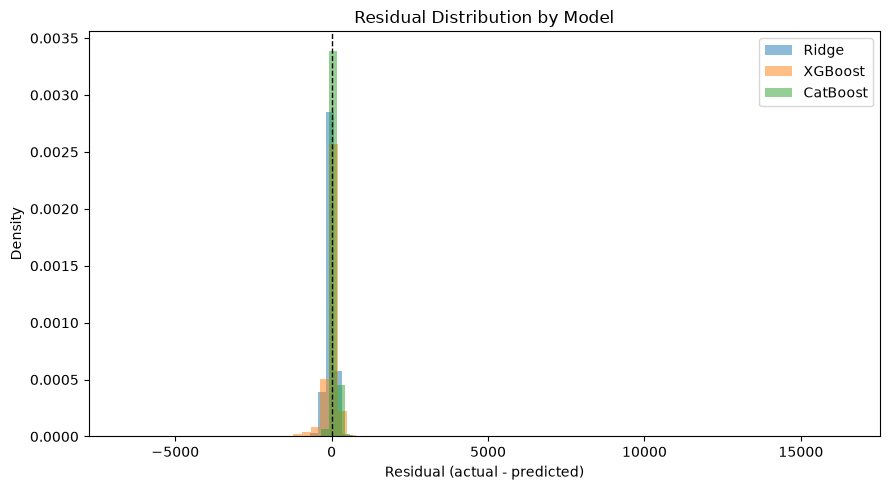

In [77]:
plt.figure(figsize=(9, 5))

for name, res in residuals.items():
    plt.hist(res, bins=80, alpha=0.5, label=name, density=True)

plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Density")
plt.title("Residual Distribution by Model")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
val = pd.read_csv("data//validation.csv")
val = val.drop(columns="load_id", errors="ignore")
val["date"] = pd.to_datetime(val["date"], errors="coerce")

val["year"] = val["date"].dt.year
val["month"] = val["date"].dt.month
val["day"] = val["date"].dt.day
val["day_of_week"] = val["date"].dt.dayofweek
val["week_of_year"] = val["date"].dt.isocalendar().week.astype(int)
val["is_weekend"] = (val["day_of_week"] >= 5).astype(int)
val["month_sin"] = np.sin(2 * np.pi * val["month"] / 12)
val["month_cos"] = np.cos(2 * np.pi * val["month"] / 12)
val["dow_sin"] = np.sin(2 * np.pi * val["day_of_week"] / 7)
val["dow_cos"] = np.cos(2 * np.pi * val["day_of_week"] / 7)

val = val.drop(columns=["date"])

X_val = val.drop(columns="posted_rate", errors="ignore") 
val_predictions = catboost_model.predict(X_val)